In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [2]:
url = (
    "https://api.worldbank.org/v2/country/all/indicator/SP.URB.TOTL.IN.ZS"
    "?format=json&per_page=20000&date=2023:2023"
)

response = requests.get(url)

data = response.json()

records = data[1]

rows = []

for item in records:

    if item["value"] is not None and item["countryiso3code"]:

        rows.append({
            "country": item["country"]["value"],
            "iso3": item["countryiso3code"],
            "urban_population_pct": item["value"]
        })

urban_df = pd.DataFrame(rows)

urban_df.head()

,country,iso3,urban_population_pct
0,Africa Eastern and Southern,AFE,37.772301
1,Africa Western and Central,AFW,52.282908
2,Arab World,ARB,59.569941
3,Caribbean small states,CSS,50.102089
4,Central Europe and the Baltics,CEB,61.697079


In [3]:
df = pd.read_csv(
    "/content/global_ml_predictions.csv"
)

In [4]:
merged_df = df.merge(
    urban_df,
    on=["country", "iso3"],
    how="left"
)

merged_df.head()

,country,iso3,population,estimated_greywater_m3_year,greywater_tons_per_hour,reuse_efficiency_pct,estimated_reused_water_m3_year,reuse_effectiveness_class,untapped_reuse_m3_year,predicted_reuse_class,urban_population_pct
0,Africa Eastern and Southern,AFE,750491370,37524568500,4.283627e+06,33.090509,1.241707e+10,Moderate,2.510750e+10,Moderate,37.772301
1,Africa Western and Central,AFW,509398589,25469929450,2.907526e+06,76.303573,1.943447e+10,Highly Effective,6.035463e+09,Highly Effective,52.282908
2,Arab World,ARB,482105978,24105298900,2.751746e+06,59.899546,1.443896e+10,Good,9.666334e+09,Good,59.569941
3,Caribbean small states,CSS,4519904,225995200,2.579854e+04,49.899386,1.127702e+08,Good,1.132250e+08,Good,50.102089
4,Central Europe and the Baltics,CEB,100183707,5009185350,5.718248e+05,16.701398,8.366040e+08,Low,4.172581e+09,Low,61.697079


In [5]:
merged_df["improved_reuse_score"] = (
    merged_df["reuse_efficiency_pct"] * 0.6
    +
    merged_df["urban_population_pct"] * 0.4
)

In [6]:
merged_df["improved_reuse_class"] = pd.cut(
    merged_df["improved_reuse_score"],
    bins=[0, 30, 50, 70, 100],
    labels=[
        "Low",
        "Moderate",
        "Good",
        "Advanced"
    ]
)

In [7]:
advanced = merged_df.sort_values(
    by="improved_reuse_score",
    ascending=False
).head(15)

advanced[
    [
        "country",
        "urban_population_pct",
        "reuse_efficiency_pct",
        "improved_reuse_score",
        "improved_reuse_class"
    ]
]

,country,urban_population_pct,reuse_efficiency_pct,improved_reuse_score,improved_reuse_class
247,Virgin Islands (U.S.),95.274079,77.499111,84.609098,Advanced
121,"Hong Kong SAR, China",100.000000,72.206847,83.324108,Advanced
134,Jordan,92.682237,75.718228,82.503831,Advanced
242,Uruguay,95.543961,73.614829,82.386482,Advanced
248,West Bank and Gaza,86.857687,77.271498,81.105974,Advanced
165,Monaco,100.000000,67.647687,80.588612,Advanced
245,"Venezuela, RB",89.249628,74.623892,80.474186,Advanced
112,Greenland,88.063115,74.727324,80.061640,Advanced
139,"Korea, Rep.",81.164555,77.883656,79.196016,Advanced
240,United Kingdom,83.160193,75.534394,78.584714,Advanced


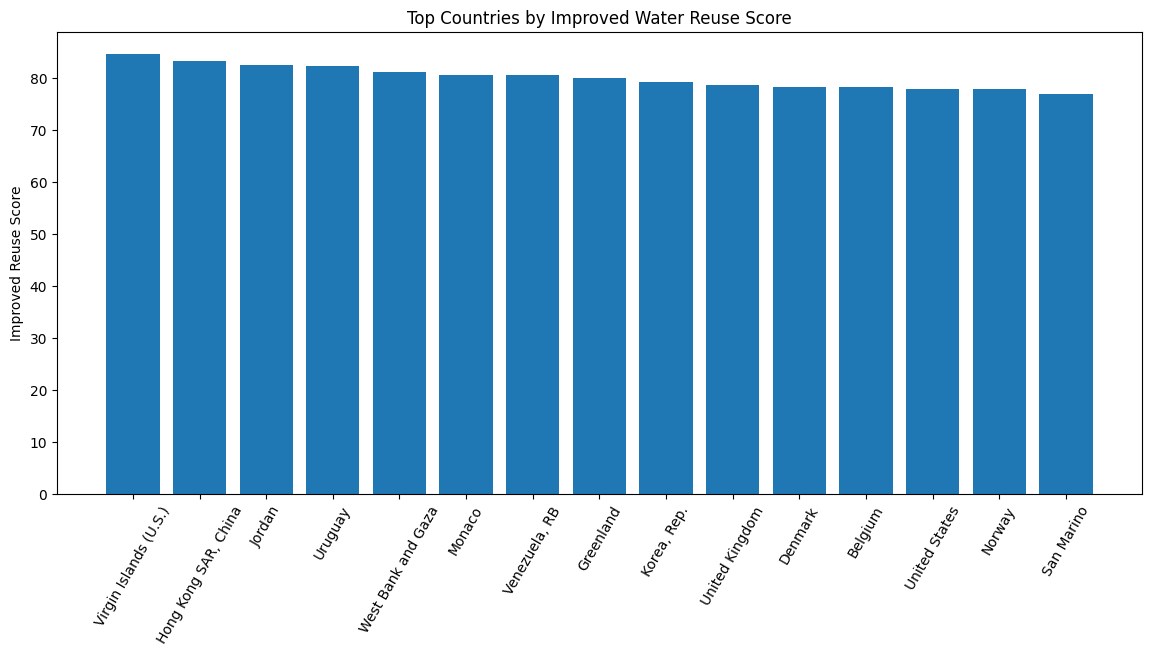

In [8]:
plt.figure(figsize=(14,6))

plt.bar(
    advanced["country"],
    advanced["improved_reuse_score"]
)

plt.xticks(rotation=60)

plt.ylabel("Improved Reuse Score")

plt.title(
    "Top Countries by Improved Water Reuse Score"
)

plt.show()

In [9]:
merged_df.to_csv(
    "global_reuse_intelligence.csv",
    index=False
)

print("Saved successfully")

Saved successfully
